In [25]:
#Import required libraries
import os
from typing import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display, Markdown

In [26]:
#Load the api key
load_dotenv(dotenv_path=r'C:\Users\User\Agentic AI\.env')
openai_key = os.getenv("OPEN_AI_KEY")
openai_client = ChatOpenAI(api_key=openai_key)

In [49]:
#Load the document
filename = input("Please enter the file name:")
loader = TextLoader(filename)
document = loader.load()
print(f"Document {filename} loaded successfully!")

Document deep_learning_material.txt loaded successfully!


In [28]:
#Lets Split the document
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)
chunks = text_splitter.split_documents(document)
print("Document splitted successfully!")
print(f"Total no of chunks:{len(chunks)}")

Document splitted successfully!
Total no of chunks:33


In [29]:
#Define embeddings
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

In [30]:
#Create vector store
vector_store = FAISS.from_documents(
    chunks,
    embeddings
)
print("Document is converted to venctors successfully!")

Document is converted to venctors successfully!


In [31]:
#Create a retriever
retriever = vector_store.as_retriever(
    search_kwargs={"k":3}
)
print("Retriever created successfully!")

Retriever created successfully!


In [32]:
#LLM
llm = ChatOpenAI(
    model = "gpt-5-mini",
    temperature= 0
)

In [33]:
class LearnMindState(TypedDict):
    context : str
    summary : str
    quiz : str
    #asnwer_key : str
    review_state : str
    summary_correct : bool
    quiz_correct : bool
    summary_retry_cnt : int
    quiz_retry_cnt : int
    user_answers : str
    answers_review : str
    

In [34]:
def retrieve_context(state: LearnMindState) -> LearnMindState:
    print("Step: Context retrieval started.....")
    docs = retriever.invoke("document summary, important points and examples")
    context = "\n\n".join(
        doc.page_content for doc in docs)
    state["context"] = context
    print("Context retrieved successfully!")
    #print(context)
    return state   

In [35]:
def summarize_text(state: LearnMindState) -> LearnMindState:
    print("Step: Summarization Agent started.....")
    context = state["context"]
    #print(context)
    prompt = f"""
You are a Professional Leaning Assistant. Who helps in making learning interesting.
You're a specialist in summarzing the content from the context provided.
Context : {context}
Summary should include the following details:
 - Consice summary
 - Important concepts or points.
 - Should also include examples.
 - Easily understanable to the user/reader.
 - Consice takeaway.
 - Suggest next topics.
 - Generate a schedule.

IMPORTANT : Use only the information from the context. Never invent new information.
 """
    response = llm.invoke(prompt)
    state["summary"] = response.content
    print("Summary generated successfully!")
    return state

In [36]:
def generate_quiz(state: LearnMindState) -> LearnMindState:
    print("Step: Quiz Generator Agent Started.....")
    context = state["context"]
    summary = state["summary"]
    quiz = state["quiz"]

    prompt = f"""
Your a Quiz generator. YOu job is to generate quiz which should inlcude the following:
 - Generate simple QUIZ for the user to answer by refering to the context, summary.
 - Quiz must have 5 questions.
 - Please provide multiple choice questions in the quiz with 4 options to choose from.
 - Also generte answer key.

 Context : {context}
 Summary : {summary}
 Quiz : {quiz}

IMPORTANT: Please generate quiz from the summary alone. Please don't invent new information.
 """
    response = llm.invoke(prompt)
    state["quiz"] = response.content
    print("Quiz generated successfully!")
    return state

In [37]:
def review_summary(state: LearnMindState)-> LearnMindState:
    print("Step: Summary Review Agent started.....")
    context = state["context"]
    summary = state["summary"]
    

    prompt=f"""
You're a context reviewer. You need to perfomr the below:
Review the summary against the context. Make sure not to invent new information.

Context : {context}
Summary : {summary}


Only respond with one word as explained below:
- Respond with YES: If the summary & Quiz are generated only from the provided cotext and are correct.
- Respond with NO: If there are any corrections required.
 """
    response = llm.invoke(prompt)
    answer = response.content.strip().upper()
    print(f"Review Completed Successfully! Result :{answer}")

    return {
        "summary_correct" : answer =="YES",
        "summary_retry_cnt" : state["summary_retry_cnt"] + 1,
        "review_state": answer

    }

In [38]:
#As we are adding the condition to review and correct we need to add conditional edge
def check_summary(state : LearnMindState) -> str:    
    if state["summary_correct"] :
            return "Summary"
    if state["summary_retry_cnt"] >=2:
        return "Summary"
    return "retry"

In [39]:
#Create node to display the summary
def display_summary(state: LearnMindState) -> LearnMindState:
        summary = state["summary"]
        paragraphs = summary.split("\n\n")
        print("\n"+"="*70)
        print("FINAL REVIEWED SUMMARY")
        print("="*70)
        display(Markdown(summary))
        #for para in paragraphs:
           #print(para.strip())
            #print()

        print("="*70)
        return state

In [40]:
def review_quiz(state: LearnMindState)-> LearnMindState:
    print("Step: Quiz Review Agent started.....")
    context = state["context"]
    summary = state["summary"]
    quiz = state["quiz"]   

    prompt=f"""
Your job is to check that quiz is correctly generated from the summary.
Context : {context}
Summary : {summary}
Quiz : {quiz}


Only respond with one word as explained below:
- Respond with YES: If the summary & Quiz are generated only from the provided cotext and are correct.
- Respond with NO: If there are any corrections required.
 """
    response = llm.invoke(prompt)
    answer = response.content.strip().upper()
    print(f"Quiz Review Completed Successfully! Review Result :{answer}")

    return {
        "quiz_correct" : answer =="YES",
        "quiz_retry_cnt" : state["quiz_retry_cnt"] + 1

    }

In [41]:
#As we are adding the condition to review and correct we need to add conditional edge
def check_quiz(state : LearnMindState) -> str:
    if state["quiz_correct"] :        
        return "Questions"
    if state["quiz_retry_cnt"] >=2: #Retry 2 times.
        return "Questions"
    return "retry"

In [42]:
#Create node to display the summary
def display_quiz(state: LearnMindState) -> LearnMindState:
        quiz = state["quiz"]
        #Remove AnswerKey from the QUIZ
        if "Answer key" in quiz:
                quiz= quiz.split("Answer key")[0]
        print("="*70)
        print("FINAL REVIEWED QUIZ")
        print("="*70)
        display(Markdown(quiz.strip()))
        return state

In [43]:
#Create a node to collect user answers
def collect_answers(state: LearnMindState)-> LearnMindState:
    print("\n"+"="*70)
    print("Please asnwer the Quiz")
    print("="*70)
    answers = input("\n Please enter your answers:")
    return {
        "user_answers": answers
    }

In [44]:
#Review answer Agent/Task
def review_answers(state: LearnMindState) -> LearnMindState:
    print("Step: User Entered Answers Evaluation Started.....")
    summary = state["summary"]
    quiz = state["quiz"]
    user_answers = state["user_answers"]
    print(f"User entered answers: {user_answers}")

    prompt = f"""   
Your a professinal learning assistant. Evaluate users answers to the quiz.
User only the provided summary and quiz.
Summary : {summary}
Quiz : {quiz}
User Answers: { user_answers}

Please provide personalized feedback which should include the following:
1. Overall performance.
2. What all questions users answered correctly.
3. What all questions user answered incorrectly.
4. Explain the incorrect answer with examples.
5. Identify the concepts that user understood well.
6. identify the concepts that user need to study again.
7. Provide recommondations for improvement.
8. Suggest the next concept to the user.

IMPORTANT: Please never invent new information that is not supported by the summary or the quiz!
Format the response in an encouraging way.
 """
    response = llm.invoke(prompt)
    feedback = response.content
    print("User provided answers review completed successfully!")

    return {
        "answers_review" : feedback
    }

In [45]:
#Create node to display the summary
def display_feedback(state: LearnMindState) -> LearnMindState:
        answers = state["answers_review"]
        #paragraphs = quiz.split("\n\n")
        print("\n"+"="*70)
        print("FINAL FEEDBACK:")
        print("="*70)
        display(Markdown(answers))
        print("="*70)
        return state

In [46]:
#Define langgraph
graph = StateGraph(LearnMindState)

#Add nodes
graph.add_node("retrieve_context",retrieve_context)
graph.add_node("summarize_text",summarize_text)
graph.add_node("review_summary", review_summary)
graph.add_node("display_summary",display_summary)
graph.add_node("quiz_generator", generate_quiz)
graph.add_node("review_quiz", review_quiz)
graph.add_node("display_quiz",display_quiz)
graph.add_node("collect_answers",collect_answers)
graph.add_node("review_answers",review_answers)
graph.add_node("display_feedback", display_feedback)


#Define the flow
graph.add_edge(START,
                "retrieve_context")

graph.add_edge("retrieve_context",
               "summarize_text")

graph.add_edge("summarize_text",
               "review_summary")

#Add conditional summary to review the summary
graph.add_conditional_edges(
    "review_summary",
    check_summary,
    {
        "retry" : "summarize_text",
        "Summary" : "display_summary"
    }
)
graph.add_edge("display_summary", 
               "quiz_generator")
graph.add_edge("quiz_generator", 
               "review_quiz")

#Add conditional edge
graph.add_conditional_edges(
    "review_quiz",
    check_quiz,
    {
        "retry" : "quiz_generator",
        "Questions" : "display_quiz"
    }

)
graph.add_edge("display_quiz", 
               "collect_answers")
graph.add_edge("collect_answers", "review_answers")
graph.add_edge("review_answers", "display_feedback")
graph.add_edge("display_feedback",END)

#Compile the graph
app = graph.compile()

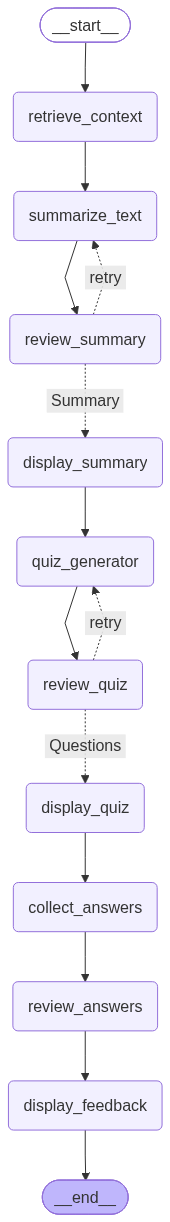

In [47]:
#View the flow
display(Image(app.get_graph().draw_mermaid_png()))

In [48]:
#Final code to invoke the graph
result = app.invoke({
    "context": "",
    "summary": "",
    "quiz" : "",
    "review_state" : "",
    "summary_correct" : False,
    "quiz_correct" : False,
    "summary_retry_cnt" : 0,
    "quiz_retry_cnt" : 0,
    "user_answers" : "",
    "answers_review" : ""
        
})



Step: Context retrieval started.....
Context retrieved successfully!
Step: Summarization Agent started.....
Summary generated successfully!
Step: Summary Review Agent started.....
Review Completed Successfully! Result :YES

FINAL REVIEWED SUMMARY


Concise summary
Deep learning is powerful at learning complex patterns from large, often unstructured data (images, audio, text) and can automatically learn features and reuse knowledge via transfer learning and pretrained models. However, it can be costly (computation, time), hard to interpret, sensitive to poor or biased training data, and often needs large amounts of data and repeated experimentation on architectures, hyperparameters, and training strategies. Attention mechanisms (including self-attention) let models focus on relevant parts of input and are key to handling long-range relationships in sequences.

Important concepts / points
- Advantages
  - Automatic feature learning (the model learns useful representations).
  - Strong performance on large, complex datasets.
  - Works well with unstructured data (images, audio, text).
  - Can learn highly complex patterns.
  - Supports transfer learning and pretrained models.
- Limitations
  - Requires significant computational resources; large models can be expensive and time-consuming to train.
  - Often needs large amounts of training data.
  - Difficult to interpret (explainability concerns).
  - Poor-quality or biased training data produces poor or biased predictions.
  - Choosing architecture, hyperparameters, and training strategy requires substantial experimentation.
- Attention mechanism
  - Lets a network focus on different input parts when producing output.
  - Self-attention computes relationships among elements within the same sequence.
  - Attention helps models determine which words matter when processing a sentence and is a main reason transformer models can handle long-range relationships.

Examples (from context)
- Attention example: when processing a sentence, attention helps the model determine which words are most relevant to understanding another word.
- Practical cost example: training large models can be expensive and time-consuming because they require significant computational resources.
- Data-quality example: biased or poor-quality training data can lead the model to make biased or poor predictions.

Easily understandable explanation
- Think of deep learning as a system that discovers its own useful features from lots of example data (especially unstructured types like images or speech). Attention is like a spotlight that highlights the most relevant parts of an input (for example, specific words in a sentence) so the model can make better decisions. But these systems need lots of data, computing power, and careful choices about model design; if the input data is poor or biased, the model’s outputs will reflect those problems.

Concise takeaway
Deep learning is powerful for complex, unstructured data and benefits from attention and transfer learning, but it demands large data and compute, careful experimentation, and attention to data quality and interpretability.

Suggested next topics to study
- Transformer models and why attention enables long-range relationships
- Transfer learning and use of pretrained models
- Data collection, labeling quality, and bias mitigation
- Model interpretability and explainability approaches
- Practical hyperparameter tuning and training strategies
- Resource- and cost-aware training practices

7-day learning schedule (starter plan)
Day 1 — Overview (1–2 hours)
- Review advantages and limitations of deep learning; note resource and data needs.

Day 2 — Data quality and bias (1–2 hours)
- Study how poor or biased training data affects predictions; list checks to assess data quality.

Day 3 — Computational costs and scaling (1–2 hours)
- Inventory compute needs and implications of large models (time, expense).

Day 4 — Model design and experimentation (1–2 hours)
- Learn about architecture choice, hyperparameters, and how experimentation is needed to find good settings.

Day 5 — Attention mechanism (1–2 hours)
- Focus on attention and self-attention; practice the sentence-level example to see how attention highlights relevant words.

Day 6 — Transfer learning and pretrained models (1–2 hours)
- Study how pretrained models can be reused to save resources and improve performance.

Day 7 — Review and plan next steps (1–2 hours)
- Summarize learnings, identify gaps, and pick one suggested next topic for deeper study.

If you want, I can turn this into a shorter 1–2 hour quick guide, expand any day into a detailed lesson plan, or make a checklist for assessing data quality and bias. Which would you prefer?

Step: Quiz Generator Agent Started.....
Quiz generated successfully!
Step: Quiz Review Agent started.....
Quiz Review Completed Successfully! Review Result :YES
FINAL REVIEWED QUIZ


Quiz (based only on the provided summary)

1) Which of the following is listed as an advantage of deep learning?
A. Requires little training data  
B. Automatic feature learning  
C. Guarantees model interpretability  
D. Eliminates the need for experimentation

2) Which of the following is a stated limitation of deep learning?
A. It always produces fully explainable models  
B. It often requires large amounts of training data  
C. It never needs computational resources  
D. It prevents biased predictions regardless of data

3) What is the main role of the attention mechanism as described in the summary?
A. To remove the need for training data  
B. To let a model focus on the most relevant parts of the input  
C. To make models fully interpretable  
D. To automatically collect higher-quality data

4) Which statement about self-attention is correct according to the summary?
A. Self-attention computes relationships between elements within the same sequence  
B. Self-attention matches elements across different datasets  
C. Self-attention is the same as transfer learning  
D. Self-attention eliminates the need for large models

5) Which approach is mentioned as a way to reuse knowledge and reduce training cost or effort?
A. Increasing model size without pretraining  
B. Transfer learning and pretrained models  
C. Randomly changing hyperparameters  
D. Avoiding attention mechanisms


Please asnwer the Quiz
Step: User Entered Answers Evaluation Started.....
User entered answers: 1.B 2.B 3.B 4.A 5.B
User provided answers review completed successfully!

FINAL FEEDBACK:


Nice work — you got every question right. Good job!

1. Overall performance
- Perfect score: 5 out of 5 correct.

2. Questions you answered correctly
- Q1: B (Automatic feature learning) — correct.
- Q2: B (Often requires large amounts of training data) — correct.
- Q3: B (Let a model focus on the most relevant parts of the input) — correct.
- Q4: A (Self-attention computes relationships between elements within the same sequence) — correct.
- Q5: B (Transfer learning and pretrained models) — correct.

3. Questions you answered incorrectly
- None — all answers were correct.

4. Explanation of incorrect answers (if any)
- No incorrect answers to explain. Since everything was correct, a brief reinforcement: each chosen answer matches the summary’s points and examples (e.g., attention as a “spotlight” on relevant words in a sentence; transfer learning as reusing pretrained models to save effort).

5. Concepts you understood well
- Automatic feature learning: that deep learning can discover useful representations from raw data.
- Main limitations: need for large datasets, high compute cost, difficulty of interpretation, and sensitivity to poor/bias training data.
- Role of attention: focusing on most relevant input parts to help model decisions.
- Self-attention: computing relationships among elements inside the same sequence.
- Transfer learning / pretrained models: reusing learned knowledge to reduce cost/effort.

6. Concepts to study again
- Although you answered all questions correctly, you may benefit from deeper study of:
  - How attention enables long-range relationships in transformer models (next logical step).
  - Practical strategies for reducing compute cost (e.g., use of pretrained models, resource-aware training).
  - Data quality checks and concrete bias-mitigation techniques.
  - Interpretability approaches (why deep models are hard to interpret and common ways to address that).

7. Recommendations for improvement
- Practice applying the ideas with short exercises: e.g., trace how attention highlights relevant words in a sample sentence (Day 5 of the 7-day plan).
- Review the suggested 7-day schedule and pick 1–2 days to expand into deeper study sessions (especially Days 5 and 6).
- Try small practical experiments or walkthroughs (reading a short tutorial on transformers or a guide on transfer learning) to reinforce conceptual understanding without heavy compute.

8. Suggested next concept to study
- Transformer models and why attention enables long-range relationships — this builds directly on what you already understand and is the next natural topic from the summary.

If you’d like, I can:
- Turn the Day 5 lesson into a short exercise demonstrating attention on a sentence, or
- Provide a 1–2 hour quick guide on transformers and attention to get you started. Which would you prefer?